# Bootstrap Validation — Naked Fixed-Param Models + Threshold Tuning (B=100)

Extension of Naked_Model_Bootstrap adding OOF threshold tuning per iteration.
Goal: compare recall and F1 stability between naked models and RF_light_grid_bootstrap.

**Threshold tuning:** OOF F1 maximized subject to precision ≥ 0.60 floor (matching Yundi's pipeline).

**Per iteration:** fit fixed-param model → OOF threshold tuning (maximize F1) → evaluate on fixed test set  
**Tracked:** test AUC · OOF threshold · precision · recall · F1 · brier

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, brier_score_loss,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [8]:
B            = 100
RANDOM_STATE = 42
N_SPLITS     = 5
BOOT_MODELS  = ['CatBoost', 'XGBoost', 'Random Forest']

FIXED_PARAMS = {
    'Random Forest': {
        'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 5,
        'max_features': 'sqrt', 'class_weight': 'balanced',
        'random_state': RANDOM_STATE, 'n_jobs': -1,
    },
    'XGBoost': {
        'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'random_state': RANDOM_STATE, 'eval_metric': 'logloss', 'verbosity': 0,
    },
    'CatBoost': {
        'iterations': 200, 'learning_rate': 0.05, 'depth': 4,
        'random_seed': RANDOM_STATE, 'verbose': 0,
    },
}

PRECISION_FLOOR = 0.60

# RF_light_grid_bootstrap bootstrap reference
LIGHT_RF_REF = {'auc': 0.7563, 'recall': 0.6861, 'f1': 0.6511, 'precision': 0.6276}

df = pd.read_csv('../df_artists_final.csv', index_col=0).reset_index()
X  = df.drop(columns=['top_20_hitmaker'])
y  = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Class balance (train): {y_train.mean():.3f} hitmaker')

Train: (607, 26)  Test: (152, 26)
Class balance (train): 0.432 hitmaker


In [9]:
def build_model(name, seed):
    p = FIXED_PARAMS[name].copy()
    if name == 'Random Forest':
        p['random_state'] = seed
        return RandomForestClassifier(**p)
    elif name == 'XGBoost':
        p['random_state'] = seed
        return XGBClassifier(**p)
    elif name == 'CatBoost':
        p['random_seed'] = seed
        return CatBoostClassifier(**p)


def run_one_model(name, X_tr, y_tr, X_te, y_te, seed):
    imp      = SimpleImputer(strategy='median')
    X_tr_imp = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns)
    X_te_imp = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    # OOF threshold tuning
    oof_proba = np.zeros(len(y_tr))
    for tr, va in skf.split(X_tr_imp, y_tr):
        m = build_model(name, seed)
        m.fit(X_tr_imp.iloc[tr], y_tr.iloc[tr])
        oof_proba[va] = m.predict_proba(X_tr_imp.iloc[va])[:, 1]

    thresholds = np.arange(0.05, 0.95, 0.01)
    f1s   = np.array([f1_score(y_tr, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
    precs = np.array([precision_score(y_tr, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
    valid_mask = precs >= PRECISION_FLOOR
    if valid_mask.any():
        best_idx = np.argmax(np.where(valid_mask, f1s, -np.inf))
    else:
        best_idx = np.argmax(precs)
    best_t = round(thresholds[best_idx], 2)

    # Final fit on full training set
    model = build_model(name, seed)
    model.fit(X_tr_imp, y_tr)
    test_proba = model.predict_proba(X_te_imp)[:, 1]
    y_pred     = (test_proba >= best_t).astype(int)

    return {
        'test_auc':  roc_auc_score(y_te, test_proba),
        'brier':     brier_score_loss(y_te, test_proba),
        'threshold': best_t,
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
    }

## Bootstrap Loop

In [10]:
METRICS  = ['test_auc', 'brier', 'threshold', 'precision', 'recall', 'f1']
results  = {name: {m: [] for m in METRICS} for name in BOOT_MODELS}
results['Baseline'] = {'test_auc': []}

rng = np.random.default_rng(RANDOM_STATE)

for b in range(B):
    seed     = RANDOM_STATE + b
    boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_tr_b   = X_train.iloc[boot_idx].reset_index(drop=True)
    y_tr_b   = y_train.iloc[boot_idx].reset_index(drop=True)

    print(f'[{b+1:02d}/{B}] ', end='', flush=True)

    for name in BOOT_MODELS:
        print(f'{name}... ', end='', flush=True)
        try:
            res = run_one_model(name, X_tr_b, y_tr_b, X_test, y_test, seed)
            for m in METRICS:
                results[name][m].append(res[m])
            print(f'AUC={res["test_auc"]:.3f} thr={res["threshold"]:.2f} '
                  f'P={res["precision"]:.3f} R={res["recall"]:.3f} F1={res["f1"]:.3f} | ',
                  end='', flush=True)
        except Exception as e:
            print(f'ERROR({e}) | ', end='', flush=True)
            for m in METRICS:
                results[name][m].append(np.nan)

    dummy = DummyClassifier(strategy='stratified', random_state=seed)
    dummy.fit(X_tr_b, y_tr_b)
    results['Baseline']['test_auc'].append(
        roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
    )
    print(f'Baseline={results["Baseline"]["test_auc"][-1]:.3f}')

    with open('Naked_Model_Bootstrap_Threshold.pkl', 'wb') as f:
        pickle.dump(results, f)

print('\nDone. Results saved to Naked_Model_Bootstrap_Threshold.pkl')

[01/100] CatBoost... AUC=0.747 thr=0.45 P=0.629 R=0.667 F1=0.647 | XGBoost... AUC=0.718 thr=0.39 P=0.583 R=0.636 F1=0.609 | Random Forest... AUC=0.732 thr=0.43 P=0.543 R=0.758 F1=0.633 | Baseline=0.492
[02/100] CatBoost... AUC=0.778 thr=0.43 P=0.701 R=0.712 F1=0.707 | XGBoost... AUC=0.750 thr=0.34 P=0.596 R=0.803 F1=0.684 | Random Forest... AUC=0.756 thr=0.45 P=0.571 R=0.788 F1=0.662 | Baseline=0.506
[03/100] CatBoost... AUC=0.775 thr=0.47 P=0.694 R=0.652 F1=0.672 | XGBoost... AUC=0.776 thr=0.41 P=0.676 R=0.697 F1=0.687 | Random Forest... AUC=0.781 thr=0.49 P=0.628 R=0.742 F1=0.681 | Baseline=0.501
[04/100] CatBoost... AUC=0.760 thr=0.34 P=0.570 R=0.803 F1=0.667 | XGBoost... AUC=0.749 thr=0.41 P=0.643 R=0.682 F1=0.662 | Random Forest... AUC=0.757 thr=0.44 P=0.520 R=0.788 F1=0.627 | Baseline=0.511
[05/100] CatBoost... AUC=0.725 thr=0.44 P=0.584 R=0.682 F1=0.629 | XGBoost... AUC=0.718 thr=0.33 P=0.535 R=0.803 F1=0.642 | Random Forest... AUC=0.742 thr=0.38 P=0.496 R=0.848 F1=0.626 | Basel

## Results

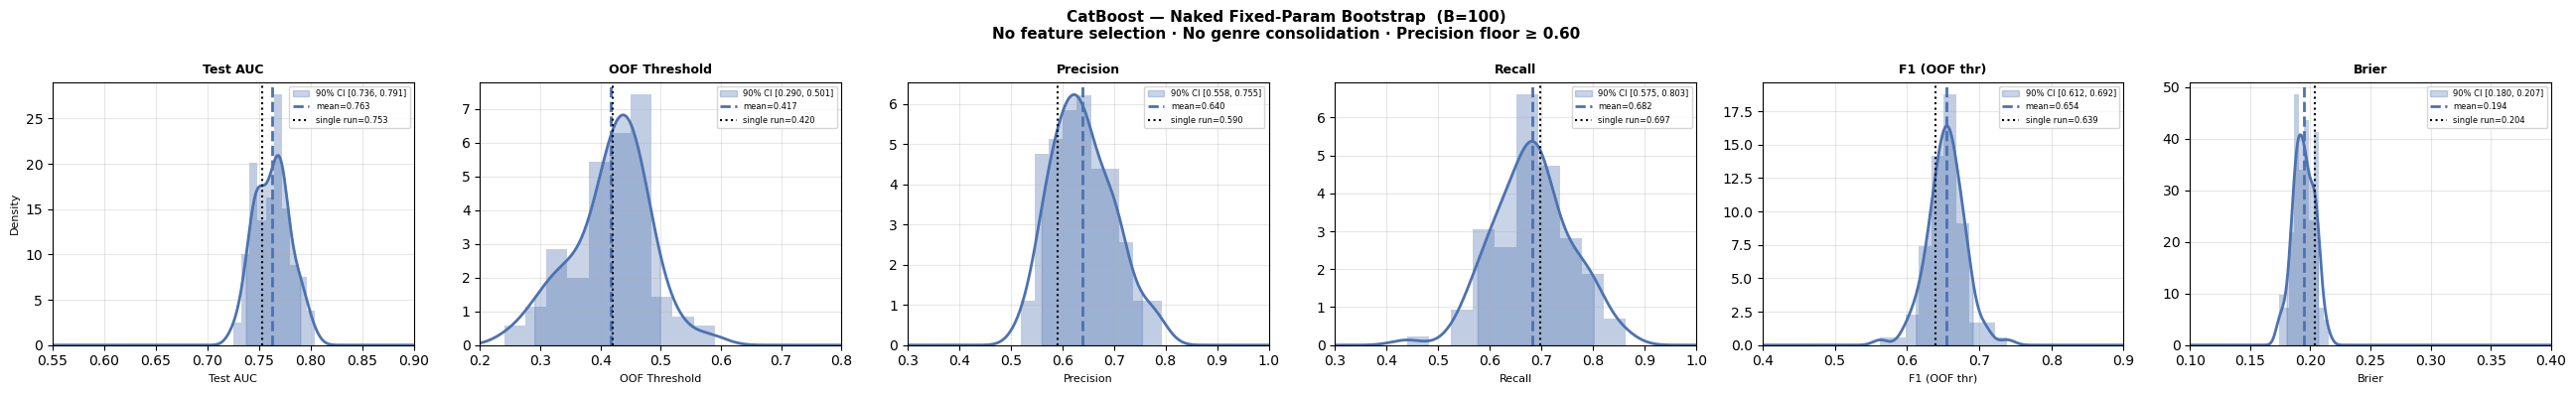

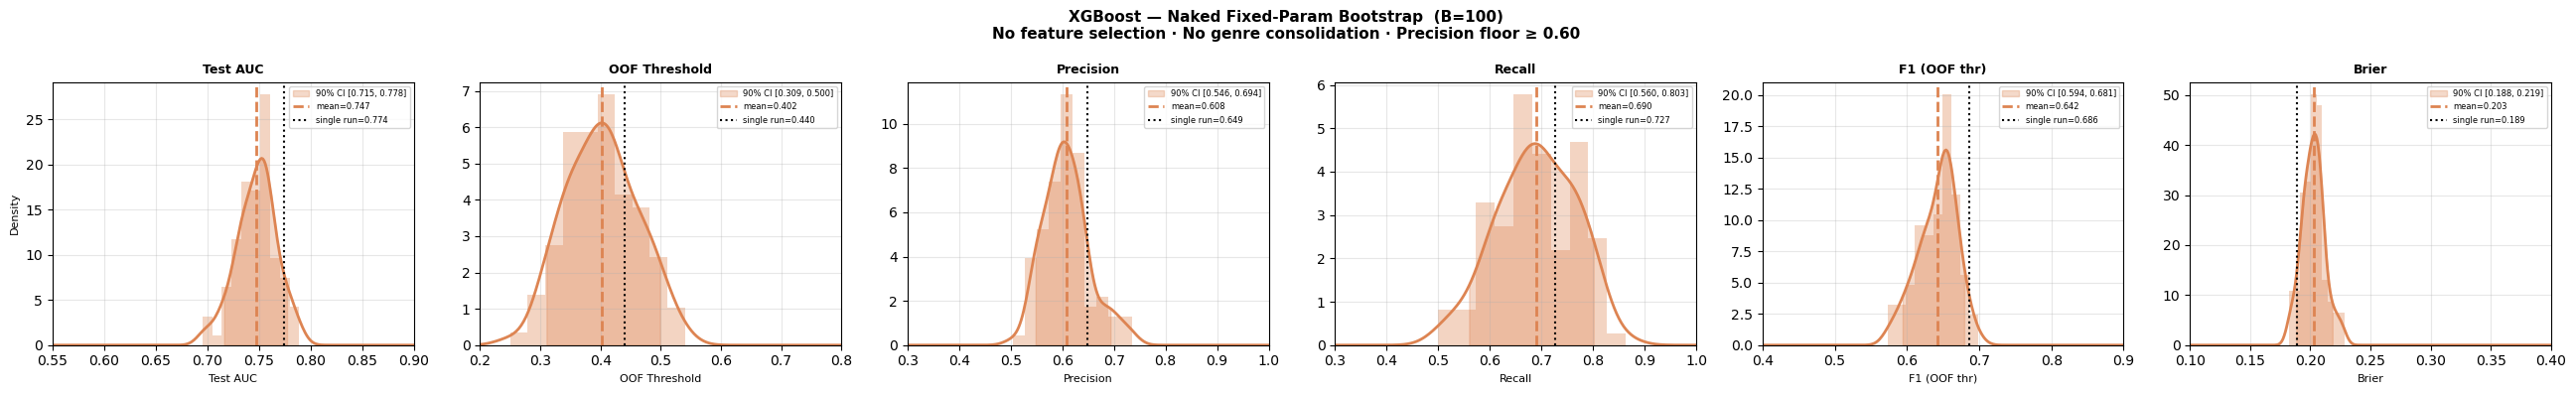

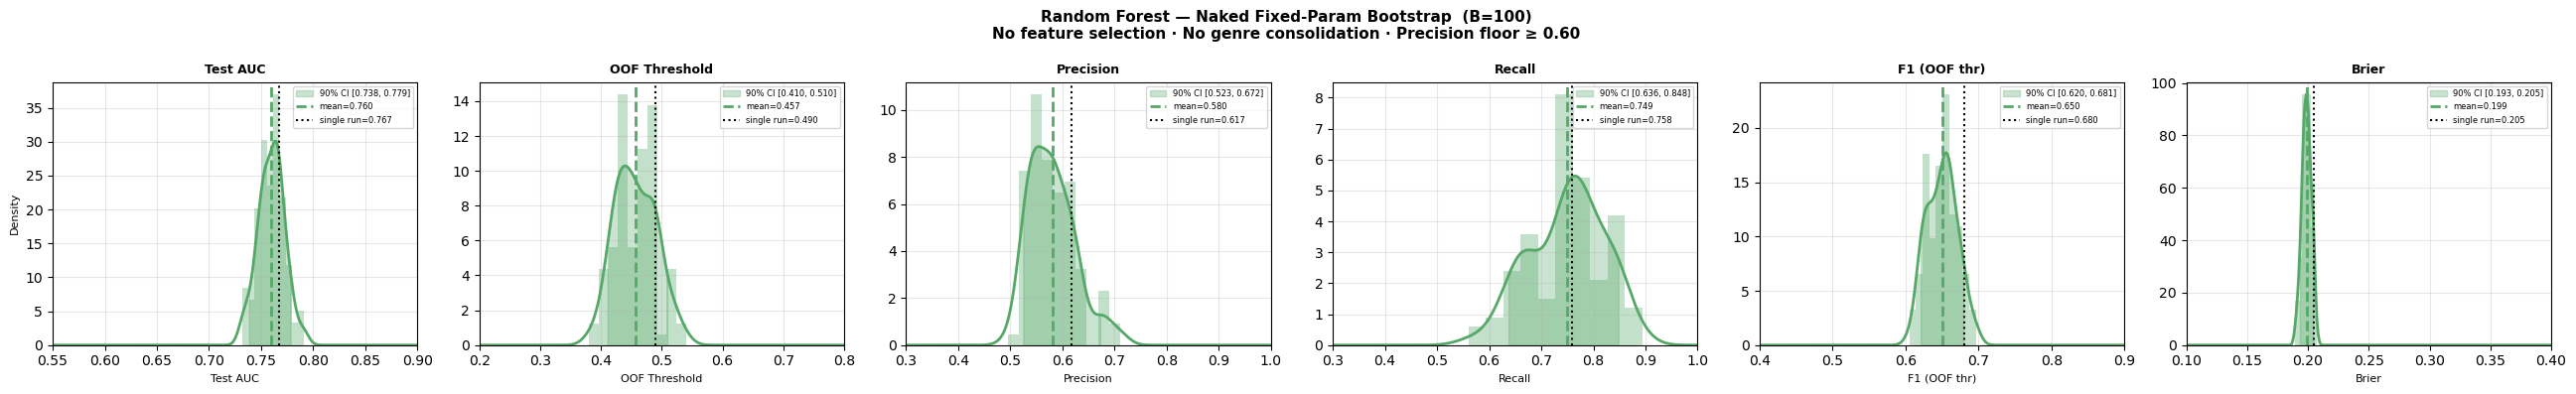

In [13]:
# ── PLOT CELL ──────────────────────────────────────────────────────────
from scipy.stats import gaussian_kde

with open('Naked_Model_Bootstrap_Threshold.pkl', 'rb') as f:
    results = pickle.load(f)

palette = {
    'CatBoost':      '#4C72B0',
    'XGBoost':       '#DD8452',
    'Random Forest': '#55A868',
}

# nb21 single-run reference values
NB21_REF = {
    'CatBoost':      {'test_auc': 0.7533, 'threshold': 0.42, 'precision': 0.590, 'recall': 0.697, 'f1': 0.639, 'brier': 0.204},
    'XGBoost':       {'test_auc': 0.7742, 'threshold': 0.44, 'precision': 0.649, 'recall': 0.727, 'f1': 0.686, 'brier': 0.189},
    'Random Forest': {'test_auc': 0.7671, 'threshold': 0.49, 'precision': 0.617, 'recall': 0.758, 'f1': 0.680, 'brier': 0.205},
}

plot_metrics = [
    ('test_auc',  'Test AUC',      (0.55, 0.90)),
    ('threshold', 'OOF Threshold', (0.20, 0.80)),
    ('precision', 'Precision',     (0.30, 1.00)),
    ('recall',    'Recall',        (0.30, 1.00)),
    ('f1',        'F1 (OOF thr)',  (0.40, 0.90)),
    ('brier',     'Brier',         (0.10, 0.40)),
]

for name in BOOT_MODELS:
    color = palette[name]
    fig, axes = plt.subplots(1, 6, figsize=(26, 4))
    fig.suptitle(
        f'{name} — Naked Fixed-Param Bootstrap  (B={B})\n'
        'No feature selection · No genre consolidation · Precision floor ≥ 0.60',
        fontsize=11, fontweight='bold'
    )

    for col, (metric, label, xlim) in enumerate(plot_metrics):
        ax   = axes[col]
        vals = [v for v in results[name][metric] if not np.isnan(v)]
        if not vals:
            ax.set_title(f'{label}\n(no data)'); continue

        mu  = np.mean(vals)
        p5  = np.percentile(vals, 5)
        p95 = np.percentile(vals, 95)
        x_grid = np.linspace(*xlim, 300)

        ax.hist(vals, bins=10, color=color, alpha=0.35, density=True)
        try:
            kde   = gaussian_kde(vals, bw_method='scott')
            y_kde = kde(x_grid)
            ax.plot(x_grid, y_kde, color=color, lw=2.0)
            mask = (x_grid >= p5) & (x_grid <= p95)
            ax.fill_between(x_grid[mask], y_kde[mask], alpha=0.30, color=color,
                            label=f'90% CI [{p5:.3f}, {p95:.3f}]')
        except Exception:
            pass

        ax.axvline(mu, color=color, lw=2.0, linestyle='--', label=f'mean={mu:.3f}')

        ref = NB21_REF[name].get(metric)
        if ref:
            ax.axvline(ref, color='black', lw=1.5, linestyle=':', label=f'single run={ref:.3f}')

        ax.set_xlabel(label, fontsize=8)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=8)
        ax.set_title(label, fontweight='bold', fontsize=9)
        ax.set_xlim(xlim)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'../../ml_sandbox/bootstrap_naked_{name.replace(" ", "_")}_plot.png', dpi=150, bbox_inches='tight')
    plt.show()


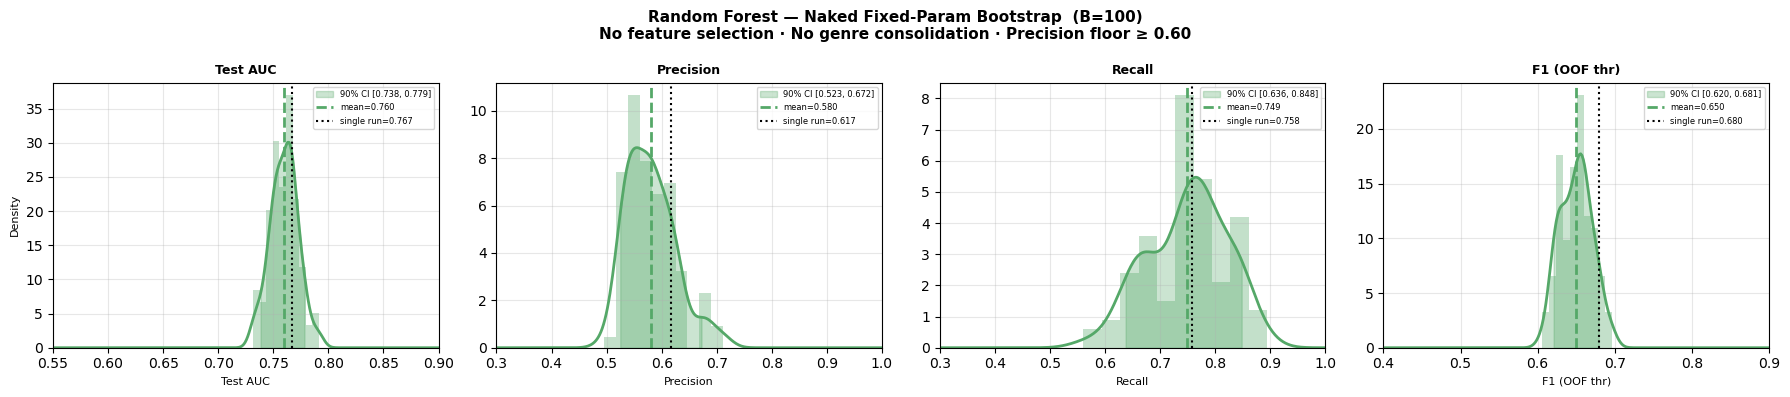

In [16]:
presentation_metrics = [
    ('test_auc',  'Test AUC',      (0.55, 0.90)),
    ('precision', 'Precision',     (0.30, 1.00)),
    ('recall',    'Recall',        (0.30, 1.00)),
    ('f1',        'F1 (OOF thr)',  (0.40, 0.90)),
]

for name in ['Random Forest']:
    color = palette[name]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(
        f'{name} — Naked Fixed-Param Bootstrap  (B={B})\n'
        'No feature selection · No genre consolidation · Precision floor ≥ 0.60',
        fontsize=11, fontweight='bold'
    )

    for col, (metric, label, xlim) in enumerate(presentation_metrics):
        ax   = axes[col]
        vals = [v for v in results[name][metric] if not np.isnan(v)]
        if not vals:
            ax.set_title(f'{label}\n(no data)'); continue

        mu  = np.mean(vals)
        p5  = np.percentile(vals, 5)
        p95 = np.percentile(vals, 95)
        x_grid = np.linspace(*xlim, 300)

        ax.hist(vals, bins=10, color=color, alpha=0.35, density=True)
        try:
            kde   = gaussian_kde(vals, bw_method='scott')
            y_kde = kde(x_grid)
            ax.plot(x_grid, y_kde, color=color, lw=2.0)
            mask = (x_grid >= p5) & (x_grid <= p95)
            ax.fill_between(x_grid[mask], y_kde[mask], alpha=0.30, color=color,
                            label=f'90% CI [{p5:.3f}, {p95:.3f}]')
        except Exception:
            pass

        ax.axvline(mu, color=color, lw=2.0, linestyle='--', label=f'mean={mu:.3f}')

        ref = NB21_REF[name].get(metric)
        if ref:
            ax.axvline(ref, color='black', lw=1.5, linestyle=':', label=f'single run={ref:.3f}')

        ax.set_xlabel(label, fontsize=8)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=8)
        ax.set_title(label, fontweight='bold', fontsize=9)
        ax.set_xlim(xlim)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [14]:
with open('Naked_Model_Bootstrap_Threshold.pkl', 'rb') as f:
    results = pickle.load(f)

NB21_REF = {
    'CatBoost':      {'test_auc': 0.7533, 'threshold': 0.42, 'precision': 0.590, 'recall': 0.697, 'f1': 0.639},
    'XGBoost':       {'test_auc': 0.7742, 'threshold': 0.44, 'precision': 0.649, 'recall': 0.727, 'f1': 0.686},
    'Random Forest': {'test_auc': 0.7671, 'threshold': 0.49, 'precision': 0.617, 'recall': 0.758, 'f1': 0.680},
}

print(f'{"": <25}  {"Test AUC":>10}  {"Recall":>10}  {"F1":>10}  {"Precision":>10}  {"Threshold":>10}')
print('─' * 85)

for name in BOOT_MODELS:
    aucs  = [v for v in results[name]['test_auc']  if not np.isnan(v)]
    recs  = [v for v in results[name]['recall']    if not np.isnan(v)]
    f1s   = [v for v in results[name]['f1']        if not np.isnan(v)]
    precs = [v for v in results[name]['precision'] if not np.isnan(v)]
    thrs  = [v for v in results[name]['threshold'] if not np.isnan(v)]

    print(f'{name + " (naked bootstrap)":<25}  {np.mean(aucs):>10.4f}  {np.mean(recs):>10.4f}  {np.mean(f1s):>10.4f}  {np.mean(precs):>10.4f}  {np.mean(thrs):>10.4f}')
    print(f'{"  std":<25}  {np.std(aucs):>10.4f}  {np.std(recs):>10.4f}  {np.std(f1s):>10.4f}  {np.std(precs):>10.4f}  {np.std(thrs):>10.4f}')

    ref = NB21_REF[name]
    print(f'{"  single run (nb21)":<25}  {ref["test_auc"]:>10.4f}  {ref["recall"]:>10.4f}  {ref["f1"]:>10.4f}  {ref["precision"]:>10.4f}  {ref["threshold"]:>10.4f}')
    print()

print('─' * 85)
print(f'{"Yundi RF (bootstrap)":<25}  {"0.7673":>10}  {"0.7618":>10}  {"0.6564":>10}  {"0.5841":>10}  {"0.45":>10}')
print(f'{"  std":<25}  {"0.0139":>10}  {"0.0673":>10}  {"0.0204":>10}  {"0.0544":>10}  {"—":>10}')
print(f'{"  single run (nb21)":<25}  {"0.7729":>10}  {"0.7121":>10}  {"0.6667":>10}  {"0.6267":>10}  {"0.50":>10}')


                             Test AUC      Recall          F1   Precision   Threshold
─────────────────────────────────────────────────────────────────────────────────────
CatBoost (naked bootstrap)      0.7628      0.6817      0.6541      0.6396      0.4172
  std                          0.0171      0.0750      0.0258      0.0597      0.0649
  single run (nb21)            0.7533      0.6970      0.6390      0.5900      0.4200

XGBoost (naked bootstrap)      0.7475      0.6900      0.6420      0.6081      0.4019
  std                          0.0194      0.0759      0.0266      0.0442      0.0590
  single run (nb21)            0.7742      0.7270      0.6860      0.6490      0.4400

Random Forest (naked bootstrap)      0.7599      0.7494      0.6500      0.5803      0.4569
  std                          0.0125      0.0710      0.0203      0.0443      0.0334
  single run (nb21)            0.7671      0.7580      0.6800      0.6170      0.4900

────────────────────────────────────────────